In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/zeynep/Desktop/python-sql-practice/data/nyc_airbnb.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [3]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [ ]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")

# Eksik bilgileri doldurma

In [5]:
df["last_review"] = pd.to_datetime(df["last_review"])

# last_review string gelir, tarihe çevrilmeli

df.dtypes

# kontrol 


id                                         int64
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood_group                          str
neighbourhood                                str
latitude                                 float64
longitude                                float64
room_type                                    str
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

In [ ]:
df.duplicated().sum()

# varsa

df = df.drop_duplicates()

np.int64(0)

In [7]:
# Outlier analizi

df["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

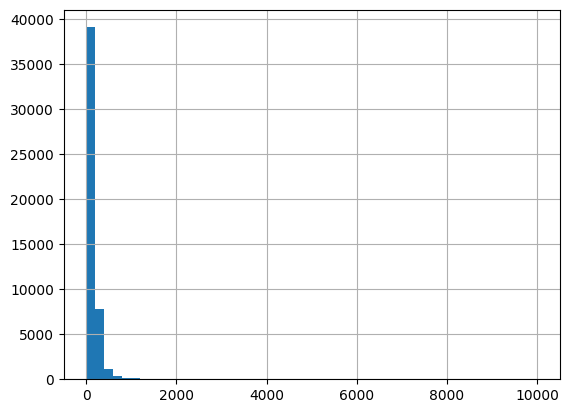

In [8]:
df["price"].hist(bins=50)
plt.show()

In [10]:
df = df[df["price"] < 1000]

In [ ]:
# Fiyat kategorisi adında bir feature

df["price_category"] = np.where(df["price"] > 200, "Expensive", "Affordable")

# Aktif listing

df["is_active"] = df["reviews_per_month"] > 0

In [11]:
df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)

neighbourhood_group
Manhattan        177.366747
Brooklyn         117.235564
Staten Island     96.148649
Queens            94.528038
Bronx             84.443526
Name: price, dtype: float64

In [12]:
df[["name", "price", "neighbourhood_group"]].sort_values("price", ascending=False).head(10)

,name,price,neighbourhood_group
10520,Clinton Hill Flat,999,Brooklyn
1899,Spacious Centrally Located Apt!!!,999,Manhattan
18519,Luxury Full-Floor 2 Bed Loft w/Huge Private Roof,999,Manhattan
14629,King 7,999,Brooklyn
46596,The Stonewall Room at Incentra Village House,999,Manhattan
36712,A Suite with breathtaking views of NYC !,999,Manhattan
48301,Private Bedroom in the Heart of Chelsea!,999,Manhattan
41585,Lahore Suite at Incentra Village House,999,Manhattan
20819,2 BDRM PRESIDENTIAL LUXURY CONDO MIDTOWN 45 N...,999,Manhattan
41400,Stable Room at Incentra Village Hotel,999,Manhattan


In [13]:
import sqlite3

conn = sqlite3.connect("/Users/zeynep/Desktop/python-sql-practice/database/nyc.db")
cursor = conn.cursor()

print("nyc.db oluşturuldu ve bağlanıldı.")

nyc.db oluşturuldu ve bağlanıldı.


In [15]:
import pandas as pd

df = pd.read_csv("/Users/zeynep/Desktop/python-sql-practice/data/nyc_airbnb.csv")
df.to_sql("airbnb", conn, if_exists="replace", index=False)
print("Veri nyc.db içindeki airbnb tablosuna yazıldı.")

# CSV yazıldı

Veri nyc.db içindeki airbnb tablosuna yazıldı.


In [16]:
pd.read_sql("SELECT COUNT(*) AS total_rows FROM airbnb", conn)

# Tabloları görmek için

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,airbnb


In [17]:
# Bağlantıyı kapamak için

conn.close()

|   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |    KENDİ ALIŞTIRMALARIM    |   |   |   |   |   |   |   |   |   |   |   |   |                                              

In [18]:
# Ortalama fiyat nedir?

df["price"].mean()


np.float64(152.7206871868289)

In [23]:
# En pahalı 10 listing

df[["name", "price", "neighbourhood_group"]].sort_values("price", ascending=False).head(10)

,name,price,neighbourhood_group
9151,Furnished room in Astoria apartment,10000,Queens
17692,Luxury 1 bedroom apt. -stunning Manhattan views,10000,Brooklyn
29238,1-BR Lincoln Center,10000,Manhattan
40433,2br - The Heart of NYC: Manhattans Lower East ...,9999,Manhattan
12342,"Quiet, Clean, Lit @ LES & Chinatown",9999,Manhattan
6530,Spanish Harlem Apt,9999,Manhattan
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,8500,Manhattan
4377,Film Location,8000,Brooklyn
29662,East 72nd Townhouse by (Hidden by Airbnb),7703,Manhattan
42523,70' Luxury MotorYacht on the Hudson,7500,Manhattan


In [24]:
# En çok review alan 10 listing

df[["neighbourhood_group", "name", "number_of_reviews"]].sort_values("number_of_reviews", ascending=False).head(10)

,neighbourhood_group,name,number_of_reviews
11759,Queens,Room near JFK Queen Bed,629
2031,Manhattan,Great Bedroom in Manhattan,607
2030,Manhattan,Beautiful Bedroom in Manhattan,597
2015,Manhattan,Private Bedroom in Manhattan,594
13495,Queens,Room Near JFK Twin Beds,576
10623,Queens,Steps away from Laguardia airport,543
1879,Manhattan,Manhattan Lux Loft.Like.Love.Lots.Look !,540
20403,Queens,Cozy Room Family Home LGA Airport NO CLEANING FEE,510
4870,Brooklyn,Private brownstone studio Brooklyn,488
471,Brooklyn,LG Private Room/Family Friendly,480


In [ ]:
# Kaç farklı neighbourhood_group var?

df["neighbourhood_group"].nunique()

5

In [29]:
# Hangi neighbourhood_group daha pahalı

df[["neighbourhood_group", "price"]].sort_values("price", ascending=False).head(1)

,neighbourhood_group,price
9151,Queens,10000


In [32]:
# Hangi neighbourhood_group'ta en fazla listing var?

df[["neighbourhood_group", "calculated_host_listings_count"]].sort_values("calculated_host_listings_count", ascending=False).head(1)

,neighbourhood_group,calculated_host_listings_count
39773,Manhattan,327


In [33]:
# Ortalama reviews_per_month nedir? 

df["reviews_per_month"].mean()

np.float64(1.3732214298586616)

In [ ]:
# Price 0 olan listing var mı?

df.loc[df["price"] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaN,NaN,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


In [ ]:
# Minimum night ortalaması nedir?

df["minimum_nights"].mean()

np.float64(7.029962163820431)

In [ ]:
# Fiyatı 200’den büyük ve reviews_per_month > 1 olan listingler

df[["name", "price", "reviews_per_month"]]

In [37]:
# Manhattan'daki listingler içinde en pahalı 5 tanesi

df.loc[
    (df["price"] > 200) & (df["reviews_per_month"] > 1),
    ["name", "price", "reviews_per_month"]
]

,name,price,reviews_per_month
16,Perfect for Your Parents + Garden,215,1.72
68,*HAVEN LOFT - Entire Floor - Six Windows - Bri...,275,1.40
70,SpaHa Loft: Enormous and Bright,225,1.64
116,2 story family home in Williamsburg,325,3.01
118,Great Large 1 BR apt in East Village!,225,1.05
...,...,...,...
47840,SoHa Bliss - Central Park North 2 Bed / 1 Bath,300,2.00
47849,PLUSH RENOVATED APARTMENT CLOSE TO MANHATTAN!,220,2.00
47994,Lovely Two Bedroom Next to Central Park,279,2.00
48096,AMAZING LARGE ONE BEDROOM IN WILLIAMSBURG!!,299,2.00


In [38]:
# Minimum nights > 10 olan listing sayısı

df.loc[
    (df["minimum_nights"] > 10),
    ["name", "minimum_nights"]
]

,name,minimum_nights
6,BlissArtsSpace!,45
14,West Village Nest - Superhost,90
29,Modern 1 BR / NYC / EAST VILLAGE,14
36,Clean and Quiet in Brooklyn,60
45,Entire apartment in central Brooklyn neighborh...,29
...,...,...
48810,UWS Spacious Master Bedroom Sublet,30
48843,"☆ HUGE, SUNLIT Room - 3 min walk from Train !",29
48871,A LARGE ROOM - 1 MONTH MINIMUM - WASHER&DRYER,29
48879,Gorgeous 1.5 Bdr with a private yard- Williams...,20


In [40]:
# Reviews sayısı 100’den fazla olan listinglerin ortalama fiyatı

df.loc[
    (df["number_of_reviews"] > 100),
    ["price"]
].mean()

price    126.413356
dtype: float64

In [45]:
# En iyi "fiyat / review" oranına sahip 10 listing

df["price_per_review"] = df["price"] / (df["number_of_reviews"] + 1)

df[["name", "price", "number_of_reviews", "price_per_review"]].sort_values("price_per_review", ascending=True).head(10)

,name,price,number_of_reviews,price_per_review
25795,Contemporary bedroom in brownstone with nice view,0,95,0.0
25794,Spacious comfortable master bedroom with nice ...,0,93,0.0
23161,"Huge Brooklyn Brownstone Living, Close to it all.",0,1,0.0
25753,"Sunny, Quiet Room in Greenpoint",0,12,0.0
26866,Best Coliving space ever! Shared room.,0,5,0.0
25433,★Hostel Style Room | Ideal Traveling Buddies★,0,55,0.0
26259,the best you can find,0,0,0.0
25778,Modern apartment in the heart of Williamsburg,0,3,0.0
25796,Cozy yet spacious private brownstone bedroom,0,95,0.0
26841,Coliving in Brooklyn! Modern design / Shared room,0,2,0.0


In [47]:
# Her neighbourhood_group için: ortalama price, max price, listing sayısı

df.groupby("neighbourhood_group")["price"].agg(
    avg_price="mean",
    max_price="max",
    listing_count="count"
).sort_values("avg_price", ascending=False)

,avg_price,max_price,listing_count
neighbourhood_group,,,
Manhattan,196.875814,10000,21661
Brooklyn,124.383207,10000,20104
Staten Island,114.812332,5000,373
Queens,99.517649,10000,5666
Bronx,87.496792,2500,1091


In [50]:
# En aktif hostlar

df.groupby("host_id").size().sort_values(ascending=False).head(10)

host_id
219517861    327
107434423    232
30283594     121
137358866    103
16098958      96
12243051      96
61391963      91
22541573      87
200380610     65
1475015       52
dtype: int64

In [51]:
# Reviews_per_month = 0 olan listingler

df[df["reviews_per_month"] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_per_review


<Axes: >

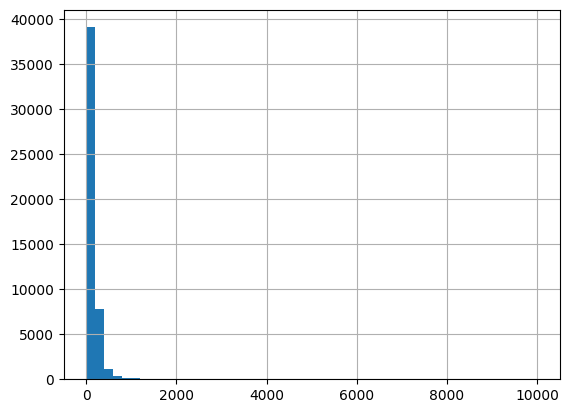

In [53]:
# Fiyat dağılımı analizi: histogram çiz, outlier var mı?

df["price"].hist(bins=50)

In [54]:
# Ucuz ama popüler listingler hangileri?" düşük price, yüksek reviews

df.loc[
    (df["price"] < 100) & (df["number_of_reviews"] > 100),
    ["name", "price", "number_of_reviews", "neighbourhood_group"]
].sort_values(["number_of_reviews", "price"], ascending=[False, True]).head(10)

,name,price,number_of_reviews,neighbourhood_group
11759,Room near JFK Queen Bed,47,629,Queens
2031,Great Bedroom in Manhattan,49,607,Manhattan
2030,Beautiful Bedroom in Manhattan,49,597,Manhattan
2015,Private Bedroom in Manhattan,49,594,Manhattan
13495,Room Near JFK Twin Beds,47,576,Queens
10623,Steps away from Laguardia airport,46,543,Queens
1879,Manhattan Lux Loft.Like.Love.Lots.Look !,99,540,Manhattan
20403,Cozy Room Family Home LGA Airport NO CLEANING FEE,48,510,Queens
471,LG Private Room/Family Friendly,60,480,Brooklyn
1271,My Little Guest Room in Flushing,55,474,Queens
